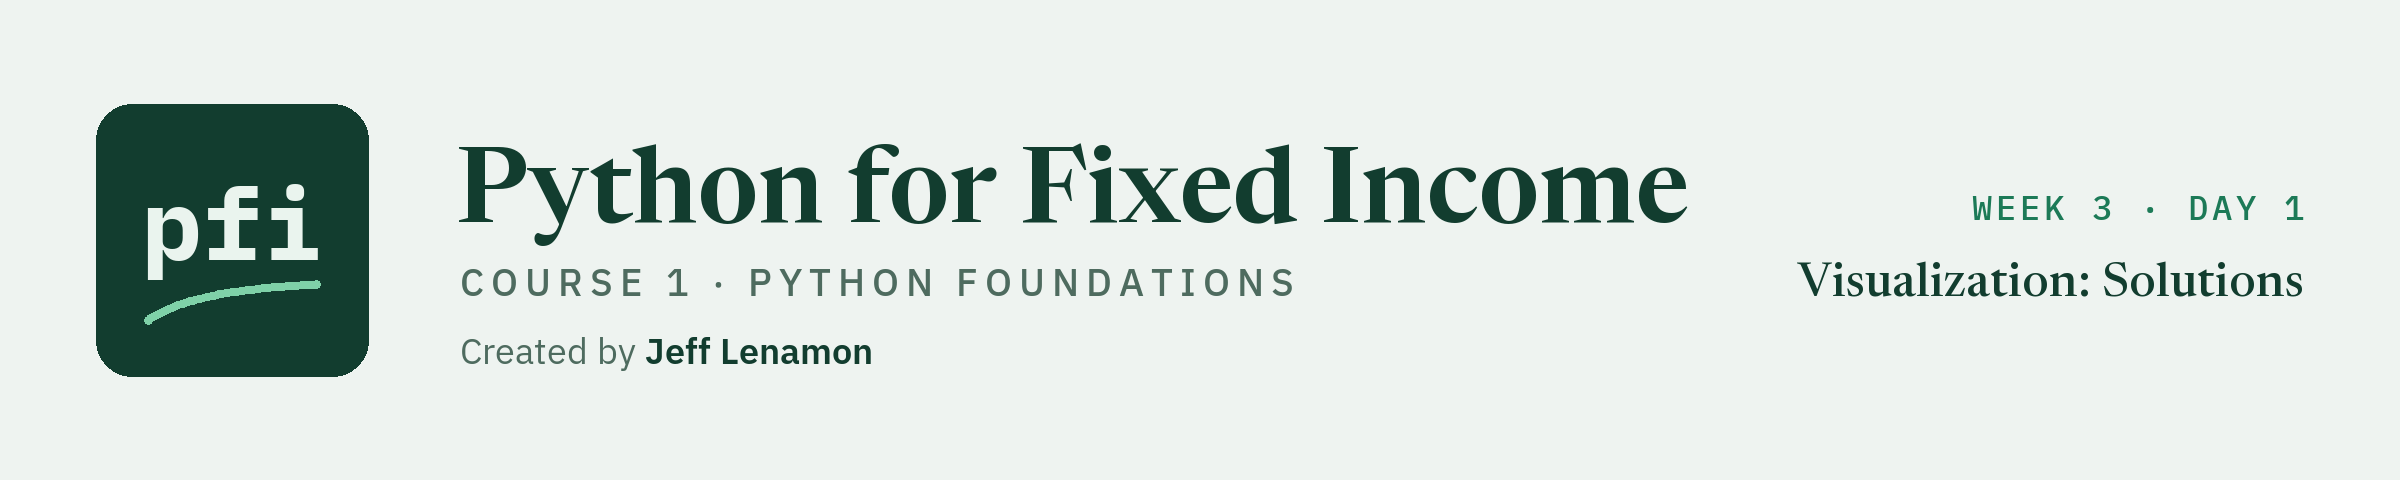

# Visualization - Solutions

Week 3. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/week3/day1/11_visualization_solutions.ipynb)

## Exercises

The lesson's charts were mostly about the OAS. The exercises use the same 200 bonds and ask about columns the lesson did not chart: duration, coupon, and yield. The issuers are invented, and every answer describes the data and is not a view.

Each exercise asks for a chart and for one or two numbers that the chart should agree with. Replace each `...` with your own code, draw the chart in the same cell or a new one, then run the check cell. Give every chart a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, loads fresh copies of the two tables, rebuilds `book` and `bucket_order`, and defines `check`, a small function that marks your answers. It prints the shape of the book, (200, 22), and the seven buckets in credit order.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the two tables. In Colab they are read from GitHub.
if os.path.exists('../../data/holdings.csv'):
    data_folder = '../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the book, rebuilt: the holdings with the score, bucket, and grade of each rating
book = pd.merge(holdings, ratings, on='rating', how='left')
bucket_order = ratings.sort_values('score')['bucket'].unique().tolist()

print(book.shape)
print(bucket_order)

(200, 22)
['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']


### Exercise 1

Q. Draw a histogram of `duration` with 15 bins. What is the mean duration of the book, rounded to 2 decimal places? How many bonds have a duration above 10 years? Store the answers in **ex1_mean** and **ex1_long**.

Mean duration: 6.47
Median duration: 6.31
Bonds with a duration above 10 years: 31


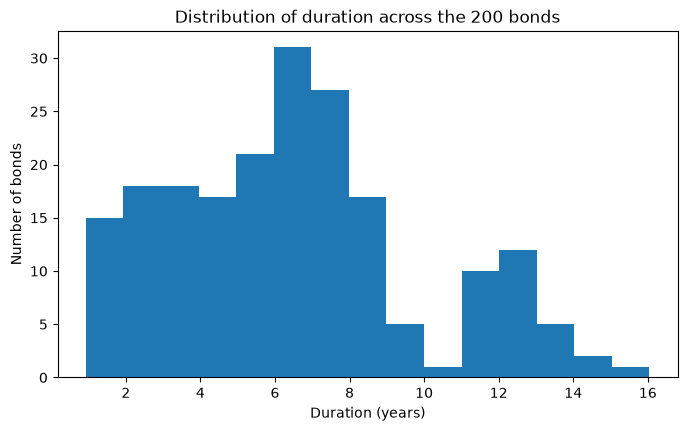

In [2]:
ex1_mean = round(book['duration'].mean(), 2)
ex1_long = (book['duration'] > 10).sum()

print('Mean duration:', ex1_mean)
print('Median duration:', round(book['duration'].median(), 2))
print('Bonds with a duration above 10 years:', ex1_long)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(book['duration'], bins=15)

ax.set_title('Distribution of duration across the 200 bonds')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('Number of bonds')

plt.show()

* The mean duration is 6.47 years, and 31 of the 200 bonds have a duration above 10 years.
* The mean and the median, 6.47 and 6.31, are close together. The duration column has a tail to the right, out to 16 years, and it is much shorter than the tail of the OAS, where the mean was 50 basis points above the median.

In [3]:
check('Exercise 1 mean', ex1_mean, 6.47)
check('Exercise 1 long bonds', ex1_long, 31)

Exercise 1 mean: correct
Exercise 1 long bonds: correct


### Exercise 2

Q. Draw a box plot of `coupon` with one box for each grade. What is the median coupon of the Investment Grade bonds, and of the High Yield bonds? Store the answers in **ex2_ig_median** and **ex2_hy_median**.

Median coupon, Investment Grade: 5.125
Median coupon, High Yield: 7.0
Third quartile, Investment Grade: 5.78125
First quartile, High Yield: 6.0625


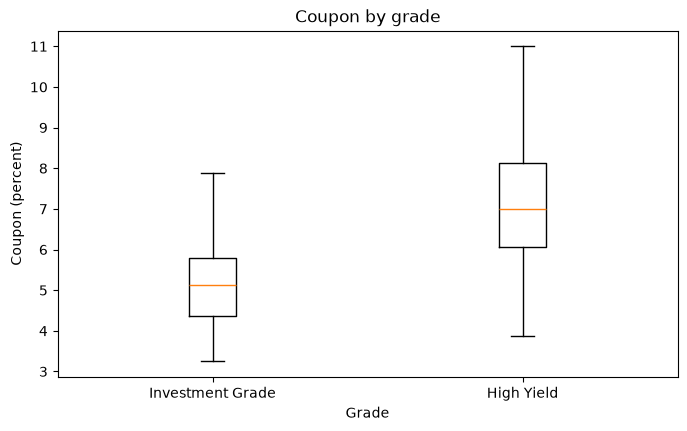

In [4]:
# the coupon column, split into the two grades
ig_coupon = book.loc[book['grade'] == 'Investment Grade', 'coupon']
hy_coupon = book.loc[book['grade'] == 'High Yield', 'coupon']

ex2_ig_median = ig_coupon.median()
ex2_hy_median = hy_coupon.median()

print('Median coupon, Investment Grade:', ex2_ig_median)
print('Median coupon, High Yield:', ex2_hy_median)

# the top of one box and the bottom of the other
print('Third quartile, Investment Grade:', ig_coupon.quantile(0.75))
print('First quartile, High Yield:', hy_coupon.quantile(0.25))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([ig_coupon, hy_coupon], tick_labels=['Investment Grade', 'High Yield'])

ax.set_title('Coupon by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Coupon (percent)')

plt.show()

* The median coupon is 5.125 percent for the Investment Grade bonds and 7.0 percent for the High Yield bonds. Those are the two lines inside the boxes.
* The High Yield box sits higher on the chart. The two boxes do not overlap: the third quartile of the Investment Grade coupons is 5.78125 percent and the first quartile of the High Yield coupons is 6.0625 percent. The whiskers do overlap. As with the OAS, the grades differ in the middle and share part of their range.

In [5]:
check('Exercise 2 Investment Grade', ex2_ig_median, 5.125)
check('Exercise 2 High Yield', ex2_hy_median, 7.0)

Exercise 2 Investment Grade: correct
Exercise 2 High Yield: correct


### Exercise 3

Q. Draw a bar chart of the average `duration` of each rating bucket, in credit order. Which bucket has the tallest bar, and how tall is it, rounded to 2 decimal places? Store the answers in **ex3_bucket** and **ex3_height**. The method `idxmax()` returns the label of the largest value in a Series.

bucket
AAA    5.67
AA     5.70
A      6.52
BBB    7.40
BB     5.84
B      5.85
CCC    4.42
Name: duration, dtype: float64


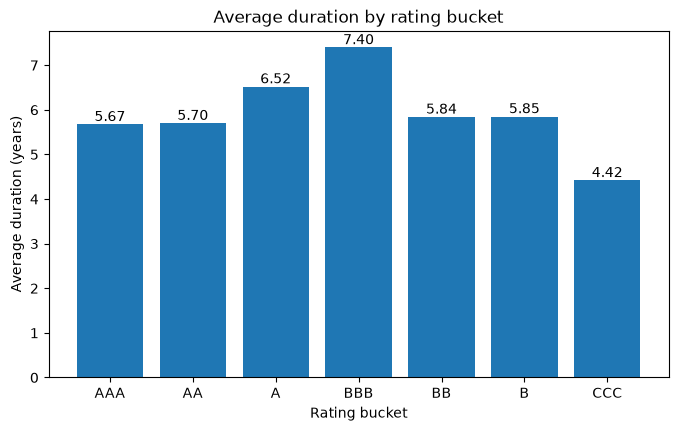

In [6]:
# the mean duration of each bucket, with the rows put in credit order
duration_by_bucket = book.groupby('bucket')['duration'].mean().loc[bucket_order]
print(duration_by_bucket.round(2))

ex3_bucket = duration_by_bucket.idxmax()
ex3_height = round(duration_by_bucket.max(), 2)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(duration_by_bucket.index, duration_by_bucket.values)
ax.bar_label(bars, fmt='%.2f')

ax.set_title('Average duration by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Average duration (years)')

plt.show()

* The BBB bucket has the tallest bar, with an average duration of 7.4 years. The shortest is CCC at 4.42 years.
* Unlike the average OAS, the average duration does not step in one direction along the rating scale. It rises from AAA to BBB and is lower in the three High Yield buckets.

In [7]:
check('Exercise 3 bucket', ex3_bucket, 'BBB')
check('Exercise 3 height', ex3_height, 7.4)

Exercise 3 bucket: correct
Exercise 3 height: correct


### Exercise 4

Q. Draw a scatter plot with `coupon` on the x axis and `yield_pct` on the y axis, with the points coloured by grade. What is the correlation of the two columns, rounded to 2 decimal places? How many bonds have a yield above their coupon? Store the answers in **ex4_corr** and **ex4_above**.

Correlation of coupon and yield: 0.74
Bonds with a yield above the coupon: 113
Bonds priced below 100: 113


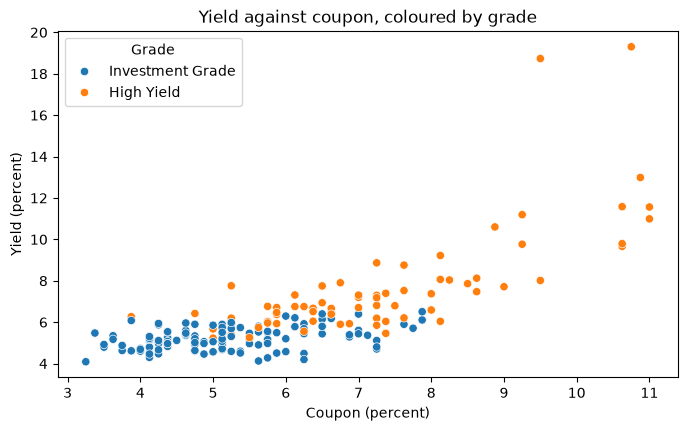

In [8]:
ex4_corr = round(book['coupon'].corr(book['yield_pct']), 2)

# a comparison of two columns gives True or False for each bond, and sum() counts the True values
ex4_above = (book['yield_pct'] > book['coupon']).sum()

print('Correlation of coupon and yield:', ex4_corr)
print('Bonds with a yield above the coupon:', ex4_above)
print('Bonds priced below 100:', (book['price'] < 100).sum())

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=book, x='coupon', y='yield_pct', hue='grade', ax=ax)
ax.legend(title='Grade')

ax.set_title('Yield against coupon, coloured by grade')
ax.set_xlabel('Coupon (percent)')
ax.set_ylabel('Yield (percent)')

plt.show()

* The correlation is 0.74, the figure in the coupon row of the lesson's heatmap. The points rise to the right in a loose band, much looser than yield against OAS.
* 113 bonds have a yield above their coupon. They are the same 113 bonds that are priced below 100: a bond whose yield is above its coupon trades at a discount. Last week's case study counted the same 113.

In [9]:
check('Exercise 4 correlation', ex4_corr, 0.74)
check('Exercise 4 above coupon', ex4_above, 113)

Exercise 4 correlation: correct
Exercise 4 above coupon: correct


### Exercise 5: AI check

You ask an AI assistant for a bar chart of the average OAS of each rating bucket, in credit order. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. How tall should the BBB bar be? The lesson worked it out in section 11.5. Then run the code. Does the chart agree with you?

* The lesson's average OAS for the BBB bucket is 127.82 basis points. The original code drew the bar labelled BBB at 503.33, with no error, and the bars did not rise from left to right.
* The bug was that the heights and the labels were in two different orders. `groupby` returns the buckets in alphabetical order: A, AA, AAA, B, BB, BBB, CCC. The code then typed the labels in credit order and drew `avg_oas.values` against them by position. So the first label, AAA, got the first value, which is the average of the A bucket, and the label BBB got the fourth value, which is the average of the B bucket.
* Every bar had a real average on it. Four of the seven were under the wrong name: AAA, A, BBB, and B. The other three, AA, BB, and CCC, are in the same position in both orders, which is why the chart looked half right.
* The fix is to put the values in the order of the labels before drawing: `.loc[labels]`. Then the name and the number travel together. The check that caught it was one number worked out earlier and compared with the chart.

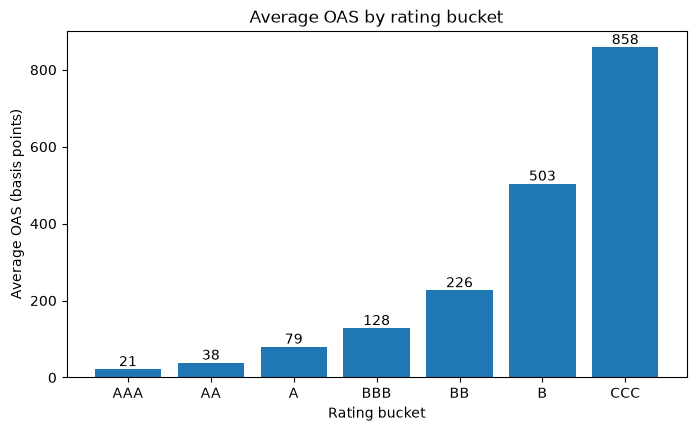

Height of the bar labelled BBB: 127.82


In [10]:
# average OAS of each rating bucket, put in credit order before it is drawn
labels = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']
avg_oas = book.groupby('bucket')['oas'].mean().loc[labels]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, avg_oas.values)
ax.bar_label(bars, fmt='%.0f')

ax.set_title('Average OAS by rating bucket')
ax.set_xlabel('Rating bucket')
ax.set_ylabel('Average OAS (basis points)')

plt.show()

# the height of the bar that carries the label BBB
ex5_bbb = round(avg_oas.values[labels.index('BBB')], 2)
print('Height of the bar labelled BBB:', ex5_bbb)

In [11]:
check('Exercise 5 BBB bar', ex5_bbb, 127.82)

Exercise 5 BBB bar: correct
